# Tutorial 19: Entry, Descent, and Landing (EDL)

This tutorial covers the dynamics of atmospheric entry, including ballistic and lifting flight paths, and aerodynamic heating estimation.

## 1. Ballistic Entry Dynamics
A ballistic entry occurs when a vehicle has no lift ($L/D = 0$). The trajectory is determined by gravity and drag.

$$\dot{v} = -\frac{\mu}{r^2} \hat{r} - \frac{1}{2}\rho v^2 \frac{C_d A}{m} \hat{v}$$

We will simulate a simplified entry from 120 km altitude.

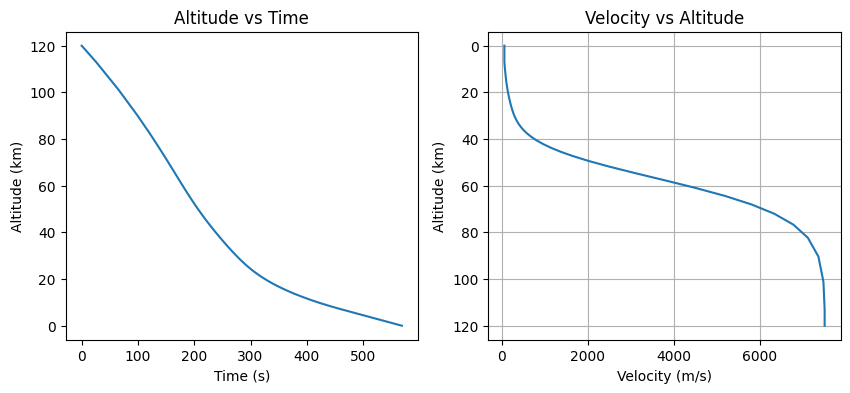

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from opengnc.edl import ballistic_entry_dynamics, sutton_grave_heating, calculate_g_load
from opengnc.environment.density import Exponential
from scipy.integrate import solve_ivp

# 1. Setup Vehicle Parameters
mass = 1000.0  # kg
area = 2.5     # m^2
cd = 1.5       # Hypersonic drag coefficient
rn = 0.5       # Nose radius (m) for heating

# 2. Initial State (120 km altitude, 7.5 km/s velocity)
alt_init = 120000.0
r_planet = 6371000.0
r0 = r_planet + alt_init
v0 = 7500.0
fpa = np.deg2rad(-2.0) # Flight path angle

state0 = np.array([
    r0, 0, 0,                      # Position (m)
    v0 * np.sin(fpa), v0 * np.cos(fpa), 0 # Velocity (m/s)
])

# 3. Simulation
# Note: Exponential density parameters (h0, H) are in kilometers!
density_model = Exponential(rho0=1.225, h0=0.0, H=8.5)

def derivatives(t, y):
    return ballistic_entry_dynamics(t, y, cd, area, mass, rho_model=density_model, r_planet=r_planet)

# Define an event to stop at ground impact
def ground_impact(t, y):
    return np.linalg.norm(y[:3]) - r_planet
ground_impact.terminal = True
ground_impact.direction = -1

sol = solve_ivp(derivatives, (0, 1000), state0, rtol=1e-6, events=ground_impact)

# 4. Post-processing
r_mags = np.linalg.norm(sol.y[:3, :], axis=0)
alts = (r_mags - r_planet) / 1000.0 # km
vels = np.linalg.norm(sol.y[3:, :], axis=0)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(sol.t, alts)
plt.title("Altitude vs Time")
plt.ylabel("Altitude (km)")
plt.xlabel("Time (s)")

plt.subplot(1, 2, 2)
plt.plot(vels, alts)
plt.title("Velocity vs Altitude")
plt.xlabel("Velocity (m/s)")
plt.ylabel("Altitude (km)")
plt.gca().invert_yaxis()
plt.grid(True)
plt.show()

## 2. Aerodynamic Heating and G-Loads
During hypersonic entry, the vehicle experiences extreme thermal loads. We can estimate the stagnation point heat flux using the Sutton-Grave correlation and monitoring the G-loads.

In [4]:
q_dots = []
g_loads = []

for i in range(len(sol.t)):
    r_vec = sol.y[:3, i]
    v_vec = sol.y[3:, i]
    v_mag = np.linalg.norm(v_vec)
    rho = density_model.get_density(r_vec, 0.0)
    
    # Heating (W/m^2 to W/cm^2)
    q = sutton_grave_heating(rho, v_mag, rn)
    q_dots.append(q / 10000.0)
    
    # G-load (based on non-gravitational acceleration)
    # The integrator derivative returns total acceleration (gravity + drag)
    total_acc = derivatives(sol.t[i], sol.y[:, i])[3:]
    # Subtract gravity to get net aero acceleration for G-load
    r_mag = np.linalg.norm(r_vec)
    mu = 3.986e14
    grav_acc = -(mu / r_mag**3) * r_vec
    aero_acc = total_acc - grav_acc
    g_loads.append(calculate_g_load(aero_acc))

print(f"Peak Heat Flux: {max(q_dots):.2f} W/cm^2")
print(f"Peak G-Load: {max(g_loads):.2f} g")
print(f"Final Velocity at Impact: {vels[-1]:.2f} m/s")

Peak Heat Flux: 152.27 W/cm^2
Peak G-Load: 8.80 g
Final Velocity at Impact: 65.39 m/s
